In [ ]:
import os
os.chdir('/Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN/code')

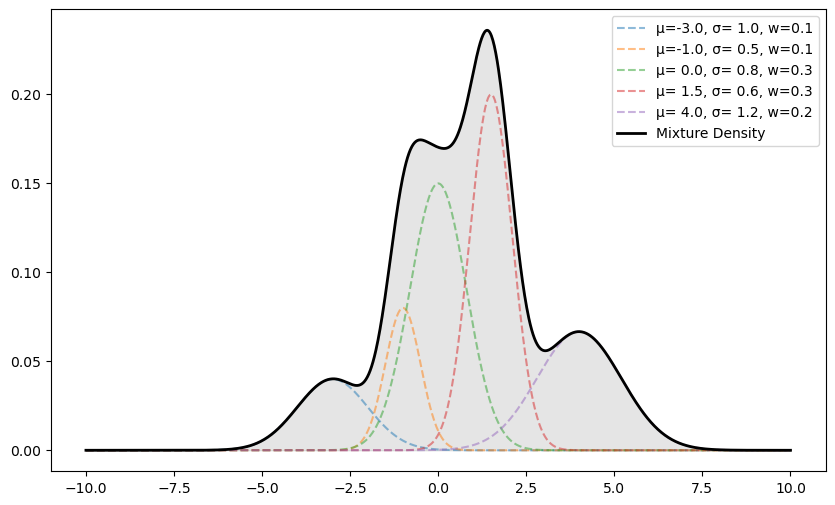

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 设置5个正态分布的参数 (均值, 标准差, 权重)
params = [(-3, 1, 0.1), (-1, 0.5, 0.1), (0, 0.8, 0.3), (1.5, 0.6, 0.3), (4, 1.2, 0.2)]

x = np.linspace(-10, 10, 1000)
mixture = np.zeros_like(x)

plt.figure(figsize=(10, 6))

for m, s, w in params:
    component = w * norm.pdf(x, m, s)
    mixture += component
    plt.plot(x, component, '--', alpha=0.5, label=f'μ={m:>4.1f}, σ={s:>4.1f}, w={w}') # 画出单个成分

# plot the 5% var or 

plt.plot(x, mixture, color='black', lw=2, label='Mixture Density') # 画出混合后的总曲线
plt.fill_between(x, mixture, color='gray', alpha=0.2)
plt.legend()
# save the figure as pdf
plt.savefig('../paper/fig/mixture_density_example.pdf',  bbox_inches='tight')
plt.show()


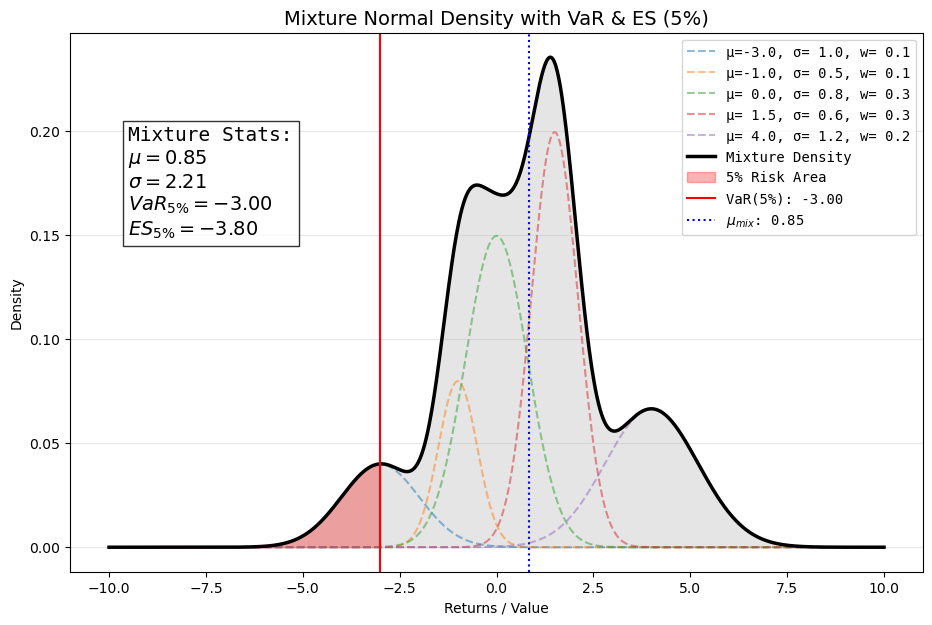

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import quad
from scipy.optimize import fsolve

# 1. 基础参数
params = [(-3, 1, 0.1), (-1, 0.5, 0.1), (0, 0.8, 0.3), (1.5, 0.6, 0.3), (4, 1.2, 0.2)]
x = np.linspace(-10, 10, 1000)

# 2. 定义混合分布的 PDF 和 CDF
def mixture_pdf(x_val):
    return sum(w * norm.pdf(x_val, m, s) for m, s, w in params)

def mixture_cdf(x_val):
    return sum(w * norm.cdf(x_val, m, s) for m, s, w in params)

# 计算混合分布的整体均值 (mu) 和 标准差 (sigma)
mix_mu = sum(w * m for m, s, w in params)
# 混合分布方差公式: E[X^2] - (E[X])^2
mix_var = sum(w * (s**2 + m**2) for m, s, w in params) - mix_mu**2
mix_sigma = np.sqrt(mix_var)

# 3. 数值计算 5% VaR
# VaR 是满足 CDF(x) = 0.05 的那个 x
var_5pct = fsolve(lambda x: mixture_cdf(x) - 0.05, -5)[0]

# 4. 数值计算 5% Expected Shortfall (ES)
# ES = (1/alpha) * integral from -inf to VaR of (x * pdf)
es_res, _ = quad(lambda x: x * mixture_pdf(x), -20, var_5pct)
es_5pct = es_res / 0.05

# --- 开始绘图 ---
plt.figure(figsize=(11, 7))
y_mixture = [mixture_pdf(val) for val in x]

# 画出单个成分
for m, s, w in params:
    # plt.plot(x, w * norm.pdf(x, m, s), '--', alpha=0.3, lw=1)
    plt.plot(x, w * norm.pdf(x, m, s), '--', alpha=0.5, label=f'μ={m:>4.1f}, σ={s:>4.1f}, w={w:>4.1f}') # 画出单个成分

# 画出混合曲线
plt.plot(x, y_mixture, color='black', lw=2.5, label='Mixture Density')

# 5. 标注 VaR 区域 (左侧 5% 尾部)
x_tail = np.linspace(-10, var_5pct, 200)
plt.fill_between(x, mixture, color='gray', alpha=0.2)
plt.fill_between(x_tail, [mixture_pdf(v) for v in x_tail], color='red', alpha=0.3, label='5% Risk Area')

# 6. 画出 VaR, ES 和 Mu 的垂直线
plt.axvline(var_5pct, color='red', linestyle='-', lw=1.5, label=f'VaR(5%): {var_5pct:.2f}') 
# plt.axvline(es_5pct, color='darkred', linestyle='-.', lw=1.5, label=f'ES(5%): {es_5pct:.2f}')
plt.axvline(mix_mu, color='blue', linestyle=':', lw=1.5, label=f'$\mu_{{mix}}$: {mix_mu:.2f}')

# 文本框标注统计量
stats_text = (f'Mixture Stats:\n'
              f'$\mu = {mix_mu:.2f}$\n'
              f'$\sigma = {mix_sigma:.2f}$\n'
              f'$VaR_{{5\%}} = {var_5pct:.2f}$\n'
              f'$ES_{{5\%}} = {es_5pct:.2f}$')
plt.text(-9.5, 0.15, stats_text, bbox=dict(facecolor='white', alpha=0.8), fontsize=14, family='monospace')

# 格式化
plt.title('Mixture Normal Density with VaR & ES (5%)', fontsize=14)
plt.xlabel('Returns / Value')
plt.ylabel('Density')
plt.legend(loc='upper right', prop={'family': 'monospace', 'size': 10})
plt.grid(axis='y', alpha=0.3)

# 保存
plt.savefig('../paper/fig/mixture_density_example.pdf',  bbox_inches='tight')
plt.show()

In [ ]:
# 每个步骤一张图, 用于动画切片 (Slices)
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import quad
from scipy.optimize import fsolve

# 确保文件夹存在
if not os.path.exists('fig'):
    os.makedirs('fig')

# 1. 基础参数与计算 (保持你的逻辑不变)
params = [(-3, 1, 0.1), (-1, 0.5, 0.1), (0, 0.8, 0.3), (1.5, 0.6, 0.3), (4, 1.2, 0.2)]
x = np.linspace(-10, 10, 1000)

def mixture_pdf(x_val):
    return sum(w * norm.pdf(x_val, m, s) for m, s, w in params)

def mixture_cdf(x_val):
    return sum(w * norm.cdf(x_val, m, s) for m, s, w in params)

mix_mu = sum(w * m for m, s, w in params)
mix_var = sum(w * (s**2 + m**2) for m, s, w in params) - mix_mu**2
mix_sigma = np.sqrt(mix_var)

var_5pct = fsolve(lambda x: mixture_cdf(x) - 0.05, -5)[0]
es_res, _ = quad(lambda x: x * mixture_pdf(x), -20, var_5pct)
es_5pct = es_res / 0.05
y_mixture = [mixture_pdf(val) for val in x]

# ==========================================
# 开始生成动画切片 (Slices)
# ==========================================

plt.figure(figsize=(11, 7))

# 统一的图表格式设置
plt.title('Mixture Normal Density with VaR & ES (5%)', fontsize=14)
plt.xlabel('Returns / Value')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.3)
# 固定 y 轴范围，防止后续加线时画面跳动 (重要！)
plt.ylim(0, max(y_mixture) * 1.2) 

# --- 阶段 1：逐个出现 Normal 线 ---
for i, (m, s, w) in enumerate(params):
    plt.plot(x, w * norm.pdf(x, m, s), '--', alpha=0.5, label=f'μ={m:>4.1f}, σ={s:>4.1f}, w={w:>4.1f}')
    plt.legend(loc='upper right', prop={'family': 'monospace', 'size': 10})
    # 保存第 1 到 5 帧
    plt.savefig(f'../paper/fig/slice_1_comp_{i+1}.pdf', bbox_inches='tight')

# --- 阶段 2：出现 Mixture 黑色粗线 ---
plt.plot(x, y_mixture, color='black', lw=2.5, label='Mixture Density')
plt.legend(loc='upper right', prop={'family': 'monospace', 'size': 10})
# 修复了你原本代码里 mixture 变量未定义的 bug
plt.fill_between(x, y_mixture, color='gray', alpha=0.1) 
# 保存第 6 帧
plt.savefig('../paper/fig/slice_2_mixture.pdf', bbox_inches='tight')

# --- 阶段 3：出现 VaR 红色区域和统计数据 ---
x_tail = np.linspace(-10, var_5pct, 200)
plt.fill_between(x_tail, [mixture_pdf(v) for v in x_tail], color='red', alpha=0.3, label='5% Risk Area')
plt.axvline(var_5pct, color='red', linestyle='-', lw=1.5, label=f'VaR(5%): {var_5pct:.2f}') 
plt.axvline(mix_mu, color='blue', linestyle=':', lw=1.5, label=f'$\mu_{{mix}}$: {mix_mu:.2f}')

stats_text = (f'Mixture Stats:\n'
              f'$\mu = {mix_mu:.2f}$\n'
              f'$\sigma = {mix_sigma:.2f}$\n'
              f'$VaR_{{5\%}} = {var_5pct:.2f}$\n'
              f'$ES_{{5\%}} = {es_5pct:.2f}$')
plt.text(-9.5, 0.15, stats_text, bbox=dict(facecolor='white', alpha=0.8), fontsize=14, family='monospace')

plt.legend(loc='upper right', prop={'family': 'monospace', 'size': 10})
# 保存第 7 帧 (终极版)
plt.savefig('../paper/fig/slice_3_final_var.pdf', bbox_inches='tight')

plt.close() # 绘图完毕，关闭内存中的画布
print("动画切片生成完毕！请查看 fig 文件夹。")

动画切片生成完毕！请查看 fig 文件夹。


In [2]:
import pandas as pd
import numpy as np
import sqlite3
import json
import torch
from scipy.stats import norm
from scipy.optimize import brentq
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import matplotlib.dates as mdates
import math
import os
import statsmodels.api as sm
from scipy import stats
from scipy.stats.mstats import winsorize
from statsmodels.stats.sandwich_covariance import cov_hac
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)  # 显示所有列
pd.set_option('display.max_rows', 100)     # 显示前100行

os.chdir('/Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN/code')

In [4]:

final_oos_df = pd.read_parquet('/Users/jianbinchen/Downloads/final_oos_df_20260430_0833.parquet')
metrics_df=pd.read_parquet('/Users/jianbinchen/Downloads/metrics_df_20260430_0833.parquet')
ES_df = pd.read_parquet('/Users/jianbinchen/Downloads/ES_df_20260430_0833.parquet') 

# micro_df = pd.read_parquet('/kaggle/input/datasets/jianbinchenuc/mdndata-1990/micro_data.parquet') 
micro_df = pd.read_parquet('/Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN/data/micro_data.parquet')

ES_df.head(5)

,permno,date,es_5,var_5,pit,crps,mean_pred,vol_pred,realized_ret
0,10001,2006-01-31,0.206538,-0.114007,0.294402,0.033755,0.048893,0.143753,-0.010537
1,10001,2006-02-28,0.201470,-0.128067,0.934015,0.123443,0.016316,0.113746,0.170394
2,10001,2006-03-31,0.231455,-0.150459,0.130540,0.066626,0.014809,0.134242,-0.094632
3,10001,2006-04-30,0.210720,-0.140014,0.421807,0.020890,0.007159,0.110451,-0.010372
4,10001,2006-05-31,0.214616,-0.138589,0.143481,0.054037,0.011786,0.114546,-0.076388


In [5]:
final_oos_df.head(5)

,permno,mthcaldt,target_ret_final,pi_vec,pi_logits_vec,mu_vec,sigma_vec
0,10001,2006-01-31,-0.010537,"[0.015028033405542374, 0.13545502722263336, 0....","[-2.011563539505005, 0.1871587187051773, 1.444...","[-0.08272793143987656, -0.042565032839775085, ...","[0.1394917070865631, 0.06708196550607681, 0.04..."
1,10001,2006-02-28,0.170394,"[0.05052301287651062, 0.25365501642227173, 0.4...","[-1.2026736736297607, 0.41087254881858826, 1.0...","[-0.08075752854347229, -0.04588505998253822, 0...","[0.12314553558826447, 0.059845004230737686, 0...."
2,10001,2006-03-31,-0.094632,"[0.030620506033301353, 0.23594412207603455, 0....","[-1.2578709125518799, 0.784054160118103, 1.504...","[-0.11996002495288849, -0.06793325394392014, 0...","[0.12538444995880127, 0.0649971216917038, 0.05..."
3,10001,2006-04-30,-0.010372,"[0.06275700032711029, 0.34848231077194214, 0.4...","[-0.6185317635536194, 1.0957856178283691, 1.29...","[-0.0883140116930008, -0.04486885666847229, 0....","[0.13345734775066376, 0.06257957220077515, 0.0..."
4,10001,2006-05-31,-0.076388,"[0.05170634016394615, 0.2132735252380371, 0.50...","[-1.1467143297195435, 0.2702806293964386, 1.14...","[-0.09211595356464386, -0.05197182297706604, 0...","[0.1261747181415558, 0.06358731538057327, 0.04..."


✅ 图表已保存至 ../paper/fig/macro_regime_weights.pdf


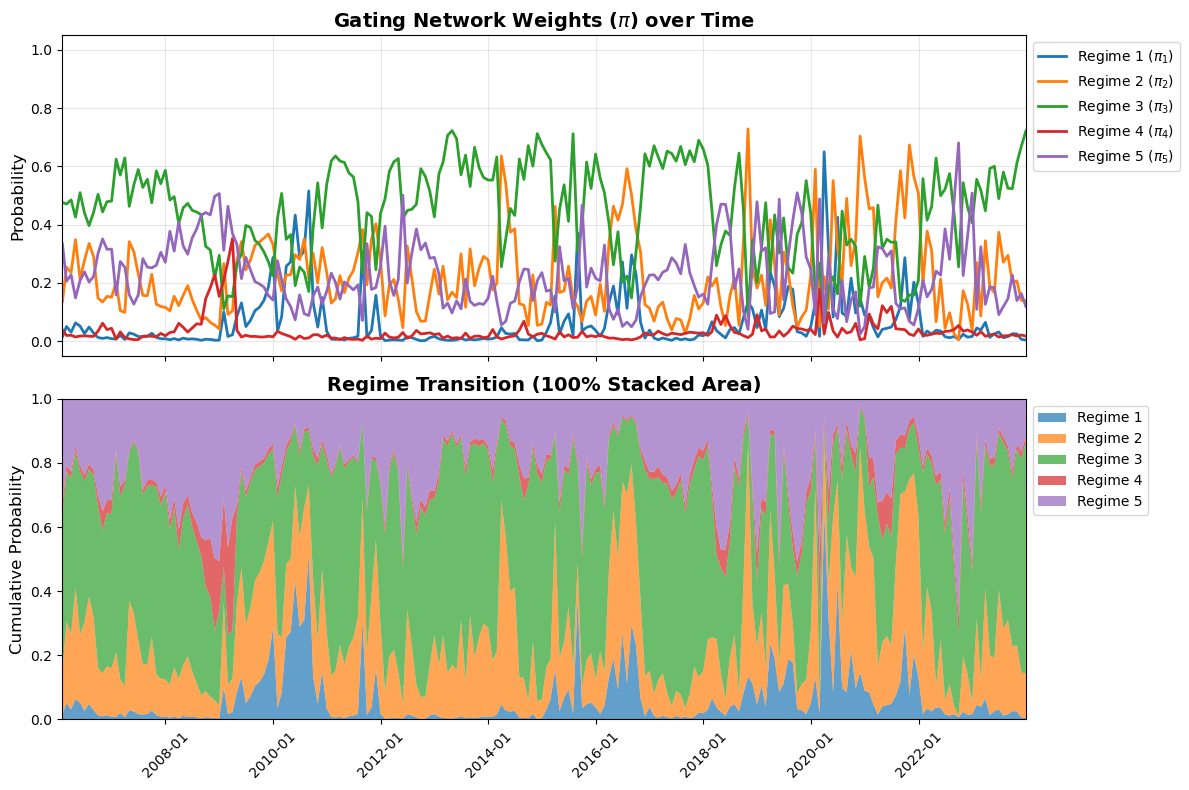

In [7]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_pi_dynamics(df_preds, time_col='mthcaldt', save_path=None):
    """
    绘制 MDN 门控网络权重 (pi_vec) 的时间序列演化图
    """
    # 1. 提取每个月的唯一 pi_vec (因为同月所有股票 pi 相同)
    df = df_preds[[time_col, 'pi_vec']].drop_duplicates(subset=[time_col]).copy()
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(time_col)
    
    # 2. 安全解析 pi_vec 字符串为 NumPy 矩阵
    if isinstance(df['pi_vec'].iloc[0], str):
        # 假设存成了 "[0.15, 0.13, 0.72]" 这样的字符串
        pi_matrix = np.vstack(df['pi_vec'].apply(json.loads).values)
    else:
        # 如果已经是 list 或 array
        pi_matrix = np.vstack(df['pi_vec'].values)
        
    num_components = pi_matrix.shape[1]
    dates = df[time_col].values
    
    # 3. 开始绘图 (双子图设计)
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    colors = plt.cm.tab10.colors  # 使用经典的学术色系
    
    # ==========================================
    # 上图：折线图 (用于精准检查数值异常)
    # ==========================================
    for k in range(num_components):
        axes[0].plot(dates, pi_matrix[:, k], label=f'Regime {k+1} ($\pi_{k+1}$)', 
                     color=colors[k], lw=2)
    
    axes[0].set_title("Gating Network Weights ($\pi$) over Time", fontsize=14, fontweight='bold')
    axes[0].set_ylabel("Probability", fontsize=12)
    axes[0].set_ylim(-0.05, 1.05) # 稍微留一点上下边距
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1)) # 图例放外侧
    
    # ==========================================
    # 下图：堆叠面积图 (展示状态的动态切换)
    # ==========================================
    axes[1].stackplot(dates, pi_matrix.T, 
                      labels=[f'Regime {k+1}' for k in range(num_components)],
                      colors=[colors[k] for k in range(num_components)], alpha=0.7)
    
    axes[1].set_title("Regime Transition (100% Stacked Area)", fontsize=14, fontweight='bold')
    axes[1].set_ylabel("Cumulative Probability", fontsize=12)
    axes[1].set_ylim(0, 1.0)
    axes[1].margins(x=0) # X轴紧贴边缘，不留白
    axes[1].legend(loc='upper left', bbox_to_anchor=(1, 1))
    
    # ==========================================
    # 优化时间轴显示
    # ==========================================
    ax = axes[1]
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    
    # 如果提供路径，则保存为高质量 PDF
    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight')
        print(f"✅ 图表已保存至 {save_path}")
        
    plt.show()

# ---------------------------------------------------------
# 🎯 调用示例
# ---------------------------------------------------------
# 直接传入你的 DataFrame 即可预览
plot_pi_dynamics(final_oos_df, save_path='../paper/fig/macro_regime_weights.pdf')

通道 1 物理特征: 中位数预期收益 = -0.1884, 预期波动 = 0.1473
通道 2 物理特征: 中位数预期收益 = -0.0809, 预期波动 = 0.0853
通道 3 物理特征: 中位数预期收益 = 0.0091, 预期波动 = 0.0686
通道 4 物理特征: 中位数预期收益 = 0.2744, 预期波动 = 0.2987
通道 5 物理特征: 中位数预期收益 = 0.1158, 预期波动 = 0.1134
✅ 图表已保存至 ../paper/fig/macro_regime_nber.pdf


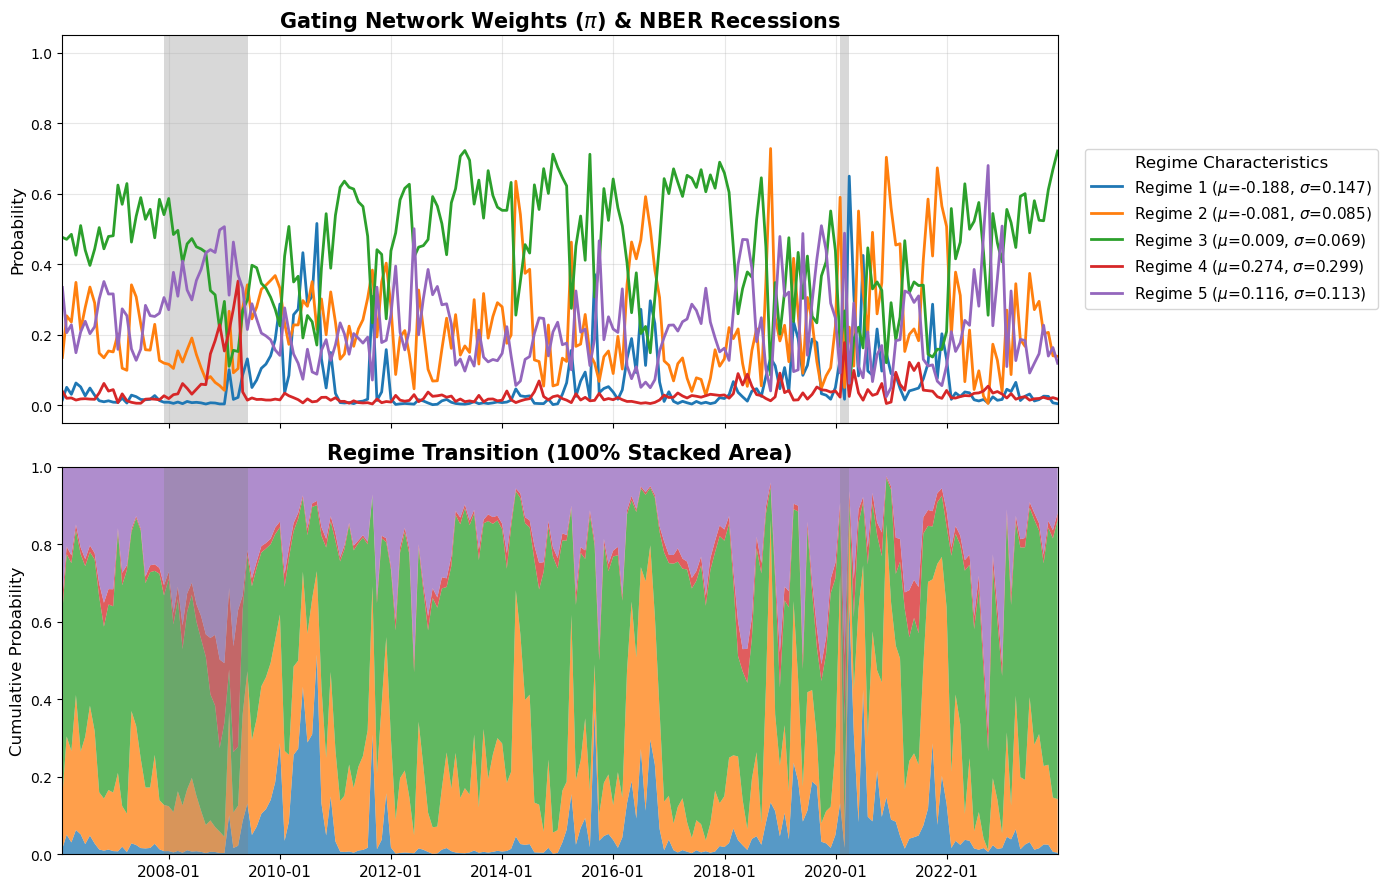

In [8]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_pi_dynamics_with_nber(df_preds, time_col='mthcaldt', save_path=None):
    """
    终极版：绘制带 NBER 衰退阴影的 MDN 状态概率图，并自动标注各通道的物理意义 (mu, sigma)
    """
    df = df_preds.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    
    # ==========================================
    # 1. 安全解析向量数据
    # ==========================================
    for col in ['pi_vec', 'mu_vec', 'sigma_vec']:
        if isinstance(df[col].iloc[0], str):
            df[f'{col}_arr'] = df[col].apply(lambda x: np.array(json.loads(x)))
        else:
            df[f'{col}_arr'] = df[col].apply(np.array)
            
    # 提取唯一的按月概率 (因为同月股票 pi 相同)
    df_pi = df[[time_col, 'pi_vec_arr']].drop_duplicates(subset=[time_col]).sort_values(time_col)
    pi_matrix = np.vstack(df_pi['pi_vec_arr'].values)
    dates = df_pi[time_col].values
    num_components = pi_matrix.shape[1]
    
    # ==========================================
    # 2. 计算每个通道的全样本中位数 mu 和 sigma
    # 目的：给每个通道赋予经济学意义
    # ==========================================
    mu_matrix = np.vstack(df['mu_vec_arr'].values)
    sigma_matrix = np.vstack(df['sigma_vec_arr'].values)
    
    median_mu = np.median(mu_matrix, axis=0)
    median_sigma = np.median(sigma_matrix, axis=0)
    
    # 动态生成富含信息的图例标签
    regime_labels = []
    for k in range(num_components):
        # 标出该通道的平均特征，让读者一目了然
        label = f'Regime {k+1} ($\mu$={median_mu[k]:.3f}, $\sigma$={median_sigma[k]:.3f})'
        regime_labels.append(label)
        print(f"通道 {k+1} 物理特征: 中位数预期收益 = {median_mu[k]:.4f}, 预期波动 = {median_sigma[k]:.4f}")

    # ==========================================
    # 3. 定义美国 NBER 经济衰退期 (2000年至今)
    # ==========================================
    nber_recessions = [
        ('2001-03-01', '2001-11-01'), # 互联网泡沫破裂
        ('2007-12-01', '2009-06-01'), # 次贷危机 (GFC)
        ('2020-02-01', '2020-04-01')  # 新冠疫情 (COVID-19)
    ]
    
    # ==========================================
    # 4. 开始绘图
    # ==========================================
    fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
    colors = plt.cm.tab10.colors 
    
    def add_nber_bands(ax):
        """辅助函数：为指定的坐标轴添加灰色阴影"""
        for start, end in nber_recessions:
            # 将字符串转为 datetime 以匹配 x 轴
            start_date = pd.to_datetime(start)
            end_date = pd.to_datetime(end)
            # 只有当衰退期在我们的数据时间范围内时才画阴影
            if start_date <= dates[-1] and end_date >= dates[0]:
                ax.axvspan(start_date, end_date, color='grey', alpha=0.3, lw=0)

    # --- 上图：折线图 ---
    for k in range(num_components):
        axes[0].plot(dates, pi_matrix[:, k], label=regime_labels[k], color=colors[k], lw=2)
    
    add_nber_bands(axes[0])
    axes[0].set_title("Gating Network Weights ($\pi$) & NBER Recessions", fontsize=15, fontweight='bold')
    axes[0].set_ylabel("Probability", fontsize=12)
    axes[0].set_ylim(-0.05, 1.05)
    axes[0].grid(True, alpha=0.3)
    # 把图例放在右侧外部，防止遮挡曲线
    axes[0].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=11, title="Regime Characteristics", title_fontsize=12)
    
    # --- 下图：堆叠面积图 ---
    axes[1].stackplot(dates, pi_matrix.T, labels=regime_labels, colors=[colors[k] for k in range(num_components)], alpha=0.75)
    
    add_nber_bands(axes[1])
    axes[1].set_title("Regime Transition (100% Stacked Area)", fontsize=15, fontweight='bold')
    axes[1].set_ylabel("Cumulative Probability", fontsize=12)
    axes[1].set_ylim(0, 1.0)
    axes[1].margins(x=0) 
    
    # --- 时间轴优化 ---
    axes[1].xaxis.set_major_locator(mdates.AutoDateLocator())
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=0, fontsize=11)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight')
        print(f"✅ 图表已保存至 {save_path}")
        
    plt.show()

# 调用示例：
plot_pi_dynamics_with_nber(final_oos_df, save_path='../paper/fig/macro_regime_nber.pdf')

🔧 检测到模型通道数 K = 5
📊 正在按照 MEDIAN of MU 进行横截面动态重排序...


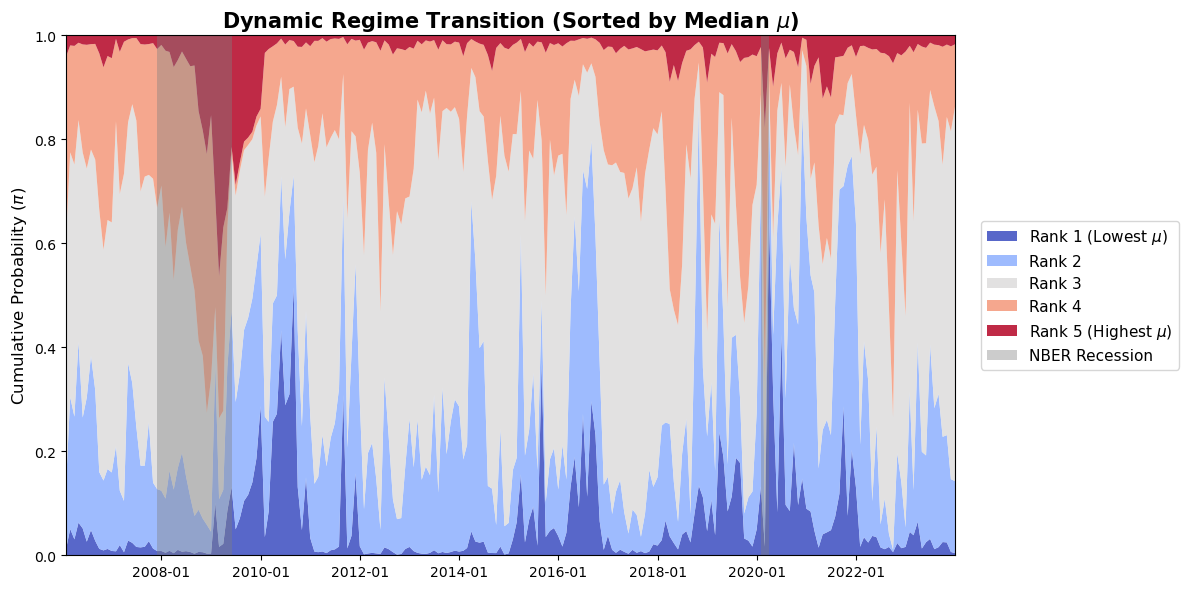

🔧 检测到模型通道数 K = 5
📊 正在按照 MEAN of SIGMA 进行横截面动态重排序...


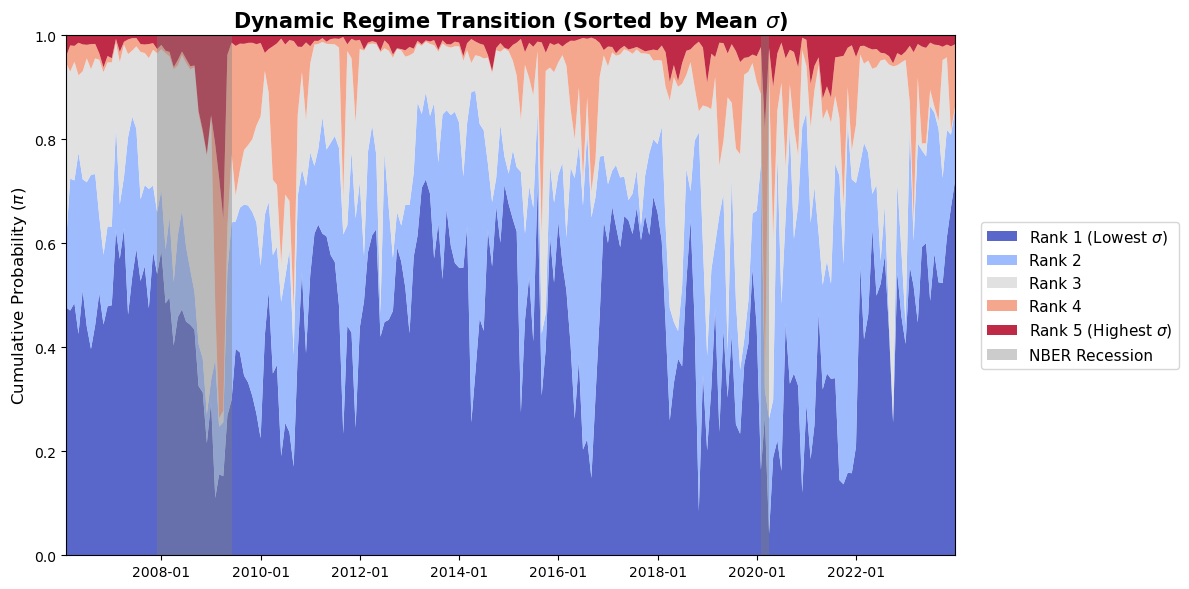

In [10]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_dynamic_sorted_pi(df_preds, time_col='mthcaldt', sort_by='mu', agg_method='median', save_path=None):
    """
    终极动态排序版：自动适应任意 K 值，并支持按 mu/sigma 和 mean/median 进行状态重排序。
    
    参数:
    - sort_by: 'mu' 或 'sigma' (决定用哪个指标来重排通道，默认 'mu')
    - agg_method: 'median' 或 'mean' (决定横截面上如何汇总数据，默认 'median')
    """
    df = df_preds.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    
    # 1. 安全解析数据，并自动识别通道数 K
    for col in ['pi_vec', 'mu_vec', 'sigma_vec']:
        if isinstance(df[col].iloc[0], str):
            df[f'{col}_arr'] = df[col].apply(lambda x: np.array(json.loads(x)))
        else:
            df[f'{col}_arr'] = df[col].apply(np.array)
            
    # 动态获取 K 值
    num_components = len(df['pi_vec_arr'].iloc[0])
    print(f"🔧 检测到模型通道数 K = {num_components}")
    print(f"📊 正在按照 {agg_method.upper()} of {sort_by.upper()} 进行横截面动态重排序...")

    # 确定使用的聚合函数
    agg_func = np.median if agg_method == 'median' else np.mean

    # 2. 逐月处理：计算指标并动态排序
    def process_month(group):
        mu_mat = np.vstack(group['mu_vec_arr'].values)
        sigma_mat = np.vstack(group['sigma_vec_arr'].values)
        
        # 计算截面汇总值 (K,)
        agg_mu = agg_func(mu_mat, axis=0)
        agg_sigma = agg_func(sigma_mat, axis=0)
        
        # 决定排序的基准指标
        if sort_by == 'mu':
            sort_metric = agg_mu
        elif sort_by == 'sigma':
            sort_metric = agg_sigma
        else:
            raise ValueError("sort_by 只能是 'mu' 或 'sigma'")
            
        pi_vec = group['pi_vec_arr'].iloc[0]
        
        # 核心：从小到大排序获取索引
        sort_idx = np.argsort(sort_metric)
        
        # 根据经济学顺序，重新排列 pi 和特征
        sorted_pi = pi_vec[sort_idx]
        sorted_metric = sort_metric[sort_idx]
        
        res = {}
        for i in range(num_components):
            res[f'pi_rank_{i}'] = sorted_pi[i]
            res[f'metric_rank_{i}'] = sorted_metric[i]
        return pd.Series(res)

    # 得到按月排序后的结果
    monthly_sorted = df.groupby(time_col).apply(process_month).reset_index()
    dates = monthly_sorted[time_col].values
    pi_matrix_sorted = monthly_sorted[[f'pi_rank_{i}' for i in range(num_components)]].values

    # 3. 动态生成图例标签 (自适应任意 K)
    metric_symbol = '$\mu$' if sort_by == 'mu' else '$\sigma$'
    regime_labels = []
    for i in range(num_components):
        if i == 0:
            desc = f"Rank 1 (Lowest {metric_symbol})"
        elif i == num_components - 1:
            desc = f"Rank {i+1} (Highest {metric_symbol})"
        else:
            desc = f"Rank {i+1}"
        regime_labels.append(desc)

    # 4. 定义美国 NBER 经济衰退期
    nber_recessions = [
        ('2001-03-01', '2001-11-01'), 
        ('2007-12-01', '2009-06-01'), 
        ('2020-02-01', '2020-04-01')  
    ]
    
    # 5. 开始绘图
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 动态渐变色：从蓝(Rank 1) 到 红(Rank K)
    colors = plt.cm.coolwarm(np.linspace(0, 1, num_components))
    
    ax.stackplot(dates, pi_matrix_sorted.T, labels=regime_labels, colors=colors, alpha=0.85)
    
    # 画 NBER 阴影
    for start, end in nber_recessions:
        start_date, end_date = pd.to_datetime(start), pd.to_datetime(end)
        if start_date <= dates[-1] and end_date >= dates[0]:
            ax.axvspan(start_date, end_date, color='grey', alpha=0.4, lw=0, 
                       label='NBER Recession' if start == '2007-12-01' else "")
            
    ax.set_title(f"Dynamic Regime Transition (Sorted by {agg_method.capitalize()} {metric_symbol})", fontsize=15, fontweight='bold')
    ax.set_ylabel("Cumulative Probability ($\pi$)", fontsize=12)
    ax.set_ylim(0, 1.0)
    ax.margins(x=0) 
    
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=0)
    
    # 调整图例
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=11)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight')
        print(f"✅ 图表已保存至 {save_path}")
        
    plt.show()

plot_dynamic_sorted_pi(final_oos_df, sort_by='mu', agg_method='median')
plot_dynamic_sorted_pi(final_oos_df, sort_by='sigma', agg_method='mean')